# Chapter 4: Setting Up Your Free Training Environment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part1_foundations/04_environment_setup.ipynb)

> **Book:** *Reinforcement Learning for Large Language Models* — Arun Shankar & Michael Chertushkin (Packt, 2025)  
> **Chapter 4:** Setting Up Your Free Training Environment  
> **Notebook:** `part1_foundations/04_environment_setup.ipynb`

---

## What this notebook covers

This notebook prepares your Colab environment for the LLM fine-tuning and RL training that begins in **Part II (Chapter 5 onwards)**. You will verify the GPU, install the training stack (`transformers`, `trl`, `peft`, `bitsandbytes`), and run a sanity-check workflow on a small Qwen2.5 model to confirm everything works before doing real fine-tuning and RLHF in later chapters. All code fits comfortably on a free Colab T4 GPU.


---
## 1. GPU Detection and Memory Audit

We check which GPU is available, how much VRAM it has, and how much is already in use. This is the first cell you should run every session — it tells you immediately whether the runtime is configured correctly.


In [1]:
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Colab: {IN_COLAB}\n')

# GPU check via PyTorch (always available in Colab)
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU       : {gpu_name}')
    print(f'VRAM total: {total_mem:.1f} GB')
    # Free memory is tricky to query before any allocation — use nvidia-smi
    try:
        result = subprocess.run(
            ['nvidia-smi',
             '--query-gpu=name,memory.total,memory.free,memory.used',
             '--format=csv,noheader,nounits'],
            capture_output=True, text=True, timeout=10
        )
        if result.returncode == 0:
            name, total, free, used = result.stdout.strip().split(', ')
            print(f'VRAM used : {int(used):,} MiB')
            print(f'VRAM free : {int(free):,} MiB')
    except Exception:
        pass
    print(f'\nCUDA version : {torch.version.cuda}')
    print(f'PyTorch      : {torch.__version__}')
else:
    print('No GPU detected. Go to Runtime -> Change runtime type -> GPU (T4).')

Running in Colab: True

GPU       : Tesla T4
VRAM total: 14.6 GB
VRAM used : 3 MiB
VRAM free : 14,910 MiB

CUDA version : 12.8
PyTorch      : 2.10.0+cu128


In [2]:
# Python and platform info
import platform

print(f'Python   : {sys.version.split()[0]}')
print(f'Platform : {platform.system()} {platform.release()}')

# RAM available (CPU side)
try:
    import psutil
    ram = psutil.virtual_memory()
    print(f'CPU RAM  : {ram.total / 1024**3:.1f} GB total,  '
          f'{ram.available / 1024**3:.1f} GB available')
except ImportError:
    # psutil not always present; skip silently
    pass

Python   : 3.12.13
Platform : Linux 6.6.122+
CPU RAM  : 12.7 GB total,  10.7 GB available


---
## 2. Installing the Training Stack

We install the full set of libraries used in this book. On Colab, this takes about 60–90 seconds. Locally, use `pip install` with the same packages.

| Library | Role |
|---|---|
| `transformers` | Model loading, tokenization, generation |
| `trl` | PPO, GRPO, DPO, SFTTrainer wrappers |
| `peft` | LoRA / QLoRA adapter layers |
| `datasets` | HuggingFace dataset streaming and caching |
| `accelerate` | Multi-GPU and mixed-precision training |
| `bitsandbytes` | 4-bit / 8-bit quantisation (BnB) |


In [3]:
if IN_COLAB:
    %pip install -q \
        transformers \
        trl \
        peft \
        datasets \
        accelerate \
        bitsandbytes \
        numpy \
        matplotlib

print('Installation complete (or skipped if running locally).')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.4 MB/s eta 0:00:00
Installation complete (or skipped if running locally).


---
## 3. Library Verification

We import each library and print its version. If any import fails, you will see a clear error message pointing to the problem package.


In [4]:
import importlib

REQUIRED = [
    ('torch',          'torch'),
    ('transformers',   'transformers'),
    ('trl',            'trl'),
    ('peft',           'peft'),
    ('datasets',       'datasets'),
    ('accelerate',     'accelerate'),
    ('bitsandbytes',   'bitsandbytes'),
    ('numpy',          'numpy'),
    ('matplotlib',     'matplotlib'),
]

all_ok = True
print(f'{'Package':<18} {'Version':<14} {'Status'}')
print('-' * 44)

for display_name, import_name in REQUIRED:
    try:
        mod = importlib.import_module(import_name)
        version = getattr(mod, '__version__', 'n/a')
        print(f'{display_name:<18} {version:<14} OK')
    except ImportError as exc:
        print(f'{display_name:<18} {"":<14} MISSING — {exc}')
        all_ok = False

print()
if all_ok:
    print('All packages present.')
else:
    print('One or more packages are missing. Re-run the install cell above.')

Package            Version        Status
--------------------------------------------
torch              2.10.0+cu128   OK
transformers       5.0.0          OK
trl                1.4.0          OK
peft               0.19.1         OK
datasets           4.8.5          OK
accelerate         1.13.0         OK
bitsandbytes       0.49.2         OK
numpy              2.0.2          OK
matplotlib         3.10.0         OK

All packages present.


---
## 4. HuggingFace Hub Authentication

Some models (e.g., Llama-2, Llama-3, Gemma) require you to accept a licence agreement on HuggingFace and then authenticate with your token. Public models like GPT-2 and Qwen/Qwen2.5-0.5B do **not** require authentication.

**Never hardcode your token in a notebook** — use Colab Secrets or `huggingface-cli login` interactively.

> Steps to obtain a token:
> 1. Create a free account at [huggingface.co](https://huggingface.co)
> 2. Go to **Settings → Access Tokens → New token** (read permission is sufficient for downloading models)
> 3. In Colab: click the key icon in the left sidebar → add secret named `HF_TOKEN`


In [5]:
import os

def setup_hf_auth():
    """Authenticate with HuggingFace Hub using a secret or env var."""
    hf_token = None

    # Option 1: Colab Secrets (recommended)
    if IN_COLAB:
        try:
            from google.colab import userdata
            hf_token = userdata.get('HF_TOKEN')
        except Exception:
            pass

    # Option 2: environment variable (local dev)
    if hf_token is None:
        hf_token = os.environ.get('HF_TOKEN')

    if hf_token:
        from huggingface_hub import login
        login(token=hf_token, add_to_git_credential=False)
        print('Logged in to HuggingFace Hub.')
    else:
        print('No HF_TOKEN found.  Public models (GPT-2, Qwen/Qwen2.5-0.5B) work without login.')
        print('For gated models add HF_TOKEN to Colab Secrets or set the env var.')


setup_hf_auth()

No HF_TOKEN found.  Public models (GPT-2, Qwen/Qwen2.5-0.5B) work without login.
For gated models add HF_TOKEN to Colab Secrets or set the env var.


---
## 5. Smoke Test — Load Qwen/Qwen2.5-0.5B and Generate Text

We load **Qwen/Qwen2.5-0.5B** (82 M parameters, ~330 MB on disk) as a smoke test. If this cell runs successfully, your environment is fully operational for all experiments in Part 1 of the book. Larger models are introduced gradually in Parts 2 and 3.


In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'Qwen/Qwen2.5-0.5B'

print(f'Loading {MODEL_ID} on {DEVICE} ...')

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)
model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters : {n_params / 1e6:.1f} M')
print(f'dtype      : {next(model.parameters()).dtype}')
print(f'Device     : {next(model.parameters()).device}')
print('Model loaded successfully.')

Loading Qwen/Qwen2.5-0.5B on cuda ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Parameters : 494.0 M
dtype      : torch.float16
Device     : cuda:0
Model loaded successfully.


---
## 6. VRAM Before and After Model Load

Tracking GPU memory usage is essential during RL training — the policy, value head, optimizer states, and rollout buffer all compete for VRAM. Here we measure the footprint of Qwen/Qwen2.5-0.5B and extrapolate to larger models.


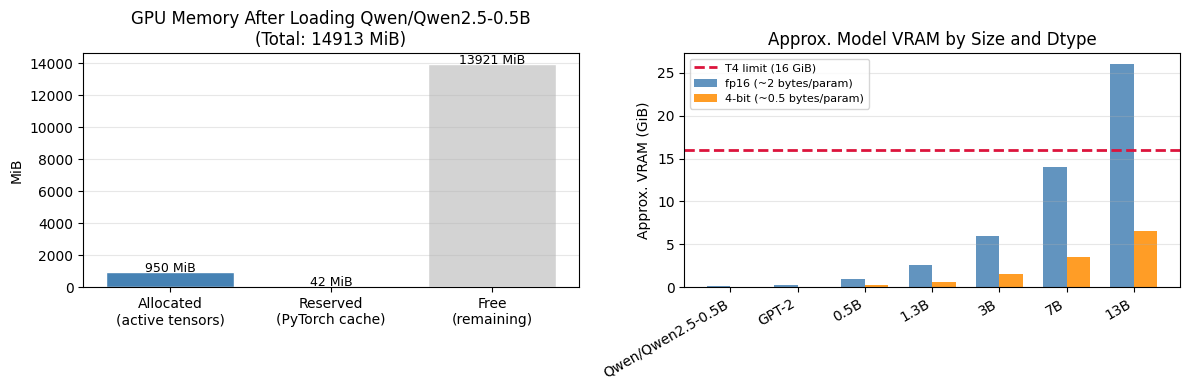


Allocated after model load : 950.2 MiB
Reserved  after model load : 992.0 MiB
T4 total                   : 14913 MiB
Available for training     : 13921 MiB


In [7]:
import matplotlib.pyplot as plt
import numpy as np

def get_gpu_memory_mib():
    """Return (allocated_MiB, reserved_MiB) from PyTorch CUDA stats."""
    if not torch.cuda.is_available():
        return 0, 0
    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved  = torch.cuda.memory_reserved(0)  / 1024**2
    return allocated, reserved


# We already loaded the model — measure current state
alloc_after, res_after = get_gpu_memory_mib()
total_mib = torch.cuda.get_device_properties(0).total_memory / 1024**2 if torch.cuda.is_available() else 16384

labels = ['Allocated\n(active tensors)', 'Reserved\n(PyTorch cache)', 'Free\n(remaining)']
values = [alloc_after, res_after - alloc_after, total_mib - res_after]
colors = ['steelblue', 'darkorange', 'lightgray']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(labels, values, color=colors, edgecolor='white')
ax1.set_ylabel('MiB')
ax1.set_title(f'GPU Memory After Loading {MODEL_ID}\n(Total: {total_mib:.0f} MiB)')
ax1.grid(alpha=0.3, axis='y')
for i, v in enumerate(values):
    ax1.text(i, v + 30, f'{v:.0f} MiB', ha='center', fontsize=9)

# Approximate VRAM for common model sizes (float16)
model_sizes_B = [0.082, 0.117, 0.5, 1.3, 3.0, 7.0, 13.0]
labels_models = ['Qwen/Qwen2.5-0.5B', 'GPT-2', '0.5B', '1.3B', '3B', '7B', '13B']
vram_fp16_GiB = [s * 2 for s in model_sizes_B]       # ~2 bytes/param in fp16
vram_4bit_GiB = [s * 0.5 for s in model_sizes_B]     # ~0.5 bytes/param in 4-bit

x = np.arange(len(model_sizes_B))
width = 0.35
ax2.bar(x - width/2, vram_fp16_GiB, width, label='fp16 (~2 bytes/param)', color='steelblue', alpha=0.85)
ax2.bar(x + width/2, vram_4bit_GiB, width, label='4-bit (~0.5 bytes/param)', color='darkorange', alpha=0.85)
ax2.axhline(16, color='crimson', linestyle='--', linewidth=2, label='T4 limit (16 GiB)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_models, rotation=30, ha='right')
ax2.set_ylabel('Approx. VRAM (GiB)')
ax2.set_title('Approx. Model VRAM by Size and Dtype')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'\nAllocated after model load : {alloc_after:.1f} MiB')
print(f'Reserved  after model load : {res_after:.1f} MiB')
print(f'T4 total                   : {total_mib:.0f} MiB')
print(f'Available for training     : {total_mib - res_after:.0f} MiB')

---
## 7. Quick Generation Verification

We run a generation call to confirm the full inference pipeline works end-to-end.


In [8]:
def generate(prompt: str, max_new_tokens: int = 60, temperature: float = 0.9) -> str:
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.92,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = output_ids[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


test_prompts = [
    'Reinforcement learning is a method that',
    'The best way to fine-tune a language model is',
]

for prompt in test_prompts:
    comp = generate(prompt, max_new_tokens=50)
    print(f'Prompt    : {prompt}')
    print(f'Completion: {comp.strip()}')
    print()

print('Generation smoke test passed.')

Prompt    : Reinforcement learning is a method that
Completion: uses a computer to make decisions based on the rewards it receives and the costs it incurs, such as the negative consequences of incorrect decisions. The most common type of reinforcement learning is a form of supervised learning in which the computer is given an initial state

Prompt    : The best way to fine-tune a language model is
Completion: to collect and train a specific subset of text that the model is known to perform well on. This process is often referred to as the "language modeling benchmarking" or "language modeling evaluation." The dataset used for this process can be diverse, including

Generation smoke test passed.


---
## 8. Mounting Google Drive (Optional)

Colab runtimes reset when the session ends — any model checkpoints saved to `/content` will be lost. Mounting Google Drive gives you a persistent 15 GB+ storage location for:
- Saved model checkpoints (`trainer.save_model`)
- Training logs
- Custom datasets

> Uncomment and run the cell below when you want to enable Drive persistence.


In [9]:
# Uncomment to mount Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# CHECKPOINT_DIR = '/content/drive/MyDrive/rl_llm_book/checkpoints'
# import os; os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# print(f'Checkpoint directory: {CHECKPOINT_DIR}')

print('Drive mount cell is ready — uncomment to activate.')

Drive mount cell is ready — uncomment to activate.


---
## 9. Free Resources Map

Everything in this book is reproducible without a paid cloud account. The table below lists the free resources we rely on and where each appears.


In [10]:
resources = [
    ('Google Colab (free tier)',     'T4 GPU, 16 GB VRAM, 12 h sessions',    'All chapters'),
    ('HuggingFace Hub',              'Model weights, tokenizers (public)',    'All chapters'),
    ('HuggingFace Datasets',         'RLHF preference data, SFT corpora',    'Ch. 5, 6, 7'),
    ('TRL (Transformers RL)',         'PPO, DPO, SFTTrainer, GRPOTrainer',   'Ch. 4 – 8'),
    ('PEFT / LoRA',                  'Parameter-efficient adapters',         'Ch. 4, 5, 7'),
    ('bitsandbytes',                 '4-bit / 8-bit quantisation',           'Ch. 4 – 8'),
    ('Weights & Biases (free plan)', 'Experiment tracking, reward curves',   'Ch. 5, 6'),
    ('GitHub',                       'Book code: arunpshankar/packt-final',  'All chapters'),
]

col_widths = [30, 42, 18]
header = (f"{'Resource':<{col_widths[0]}}  "
          f"{'What it provides':<{col_widths[1]}}  "
          f"{'Used in'}")
print(header)
print('-' * (sum(col_widths) + 6))
for name, provides, chapters in resources:
    print(f'{name:<{col_widths[0]}}  {provides:<{col_widths[1]}}  {chapters}')

Resource                        What it provides                            Used in
------------------------------------------------------------------------------------------------
Google Colab (free tier)        T4 GPU, 16 GB VRAM, 12 h sessions           All chapters
HuggingFace Hub                 Model weights, tokenizers (public)          All chapters
HuggingFace Datasets            RLHF preference data, SFT corpora           Ch. 5, 6, 7
TRL (Transformers RL)           PPO, DPO, SFTTrainer, GRPOTrainer           Ch. 4 – 8
PEFT / LoRA                     Parameter-efficient adapters                Ch. 4, 5, 7
bitsandbytes                    4-bit / 8-bit quantisation                  Ch. 4 – 8
Weights & Biases (free plan)    Experiment tracking, reward curves          Ch. 5, 6
GitHub                          Book code: arunpshankar/packt-final         All chapters


---
## 10. Session Checklist

Run this cell at the start of any new Colab session to confirm the environment is ready before starting a long training run.


In [11]:
import importlib

checks = {
    'GPU available'         : torch.cuda.is_available(),
    'VRAM >= 14 GiB'        : (
        torch.cuda.get_device_properties(0).total_memory / 1024**3 >= 14
        if torch.cuda.is_available() else False
    ),
    'transformers installed': importlib.util.find_spec('transformers') is not None,
    'trl installed'         : importlib.util.find_spec('trl') is not None,
    'peft installed'        : importlib.util.find_spec('peft') is not None,
    'bitsandbytes installed': importlib.util.find_spec('bitsandbytes') is not None,
    'datasets installed'    : importlib.util.find_spec('datasets') is not None,
    'accelerate installed'  : importlib.util.find_spec('accelerate') is not None,
}

print('=== Colab Session Readiness Check ===')
all_pass = True
for check, result in checks.items():
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_pass = False
    print(f'  [{status}]  {check}')

print()
if all_pass:
    print('Environment is fully ready.  Happy training!')
else:
    print('One or more checks failed.  See the cells above for remediation steps.')

=== Colab Session Readiness Check ===
  [PASS]  GPU available
  [PASS]  VRAM >= 14 GiB
  [PASS]  transformers installed
  [PASS]  trl installed
  [PASS]  peft installed
  [PASS]  bitsandbytes installed
  [PASS]  datasets installed
  [PASS]  accelerate installed

Environment is fully ready.  Happy training!


---
## Summary

| Step | What we did | Why it matters |
|---|---|---|
| GPU check | Queried CUDA device and VRAM | Catch misconfigured runtimes early |
| Install stack | transformers, trl, peft, etc. | All training in the book uses these |
| Verify imports | Printed version table | Reproducibility across sessions |
| HF auth | Token from Secrets / env var | Required for gated models |
| Smoke test | Qwen/Qwen2.5-0.5B generate() | Confirms full inference pipeline |
| VRAM chart | Allocated vs. total | Plan capacity before large runs |
| Drive mount | Optional persistence | Survives runtime resets |
| Resources map | Colab, Hub, TRL, PEFT | Zero cost for all book experiments |

In **Chapter 5** we move beyond setup and train our first reward model — a neural network that learns to score responses according to human preferences, providing the reward signal that RL needs.
